# COGS 108 - EDA Checkpoint

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os
from scipy.stats import ttest_ind
import seaborn as sns

In [4]:
from pathlib import Path
ROOT = Path.cwd()

file1_path = ROOT / "data" / "01-interim" / "file_adult_clothing_sales.csv"


df_ow= pd.read_csv(file1_path)
df_ow.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Delivery_Charges,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Product_Gender
0,2170,17850.0,M,Chicago,12.0,16682.0,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,6.5,Not Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men
1,2171,17850.0,M,Chicago,12.0,16697.0,2019-01-01,GGOEGAAJ073414,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,6.5,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men
2,2172,17850.0,M,Chicago,12.0,16704.0,2019-01-01,GGOEGAPB058615,Google Women's Yoga Jacket Black,Apparel,...,6.5,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Women
3,2173,17850.0,M,Chicago,12.0,16706.0,2019-01-01,GGOEGAAB010517,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,6.5,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men
4,2174,17850.0,M,Chicago,12.0,16715.0,2019-01-01,GGOEYAFB073115,YouTube Men's Fleece Hoodie Black,Apparel,...,6.5,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men


### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [3]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [8]:
df_ow['Product_Description'].unique()[:50]

<ArrowStringArray>
[     'Google Men's 100% Cotton Short Sleeve Hero Tee Black',
                'Google Men's Short Sleeve Hero Tee Heather',
                          'Google Women's Yoga Jacket Black',
                         'YouTube Men's Fleece Hoodie Black',
                 'YouTube Men's Short Sleeve Hero Tee Black',
        'Google Men's 100% Cotton Short Sleeve Hero Tee Red',
                'Google Women's Short Sleeve Hero Tee White',
               'Google Women's Quilted Insulated Vest Black',
               'Google Men's Bike Short Sleeve Tee Charcoal',
       'Google Men's 100% Cotton Short Sleeve Hero Tee Navy',
                'Google Women's Short Sleeve Hero Tee Black',
             'Google Women's Short Sleeve Hero Tee Sky Blue',
          'Google Women's Short Sleeve Hero Tee Red Heather',
                         'Google Men's Pullover Hoodie Grey',
             'Google Women's Lightweight Microfleece Jacket',
        'Android Men's Short Sleeve Tri-blend Hero 

Since the dataset does not include a dedicated “Outerwear” category, we identified outerwear items using keyword matching on the Product_Description column. Products were classified as outerwear if their descriptions contained terms such as Jacket, Hoodie, Vest, Fleece, Pullover, Insulated, or Zip.

The filtering was performed using case-insensitive string matching. We then reviewed the results to ensure that the selected items appropriately represent outerwear products.

In [23]:
outerwear_terms = [
    'jacket',
    'hoodie',
    'vest',
    'fleece',
    'pullover',
    'insulated',
    'zip'
]

def classify_outerwear(desc: str) -> bool:
    desc = str(desc).lower()
    return any(term in desc for term in outerwear_terms)

In [26]:
df_ow['Is_Outerwear'] = df_ow['Product_Description'].apply(classify_outerwear)

outerwear_df = df_ow[df_ow['Is_Outerwear']].copy()

os.makedirs('data/02-processed', exist_ok=True)

outerwear_df.to_csv('data/02-processed/outerwear_processed.csv', index=False)

## Results

### Exploratory Data Analysis





#### Section 1 of EDA - Outerwear

In this section, we focus on analyzing outerwear products within the dataset. Since the original data does not include a dedicated “Outerwear” category, we identified relevant products using keyword-based filtering on the Product_Description column. Items containing terms such as Jacket, Hoodie, Vest, Fleece, Pullover, Insulated, or Zip were classified as outerwear.

Using this filtered subset, we explore sales patterns, pricing distributions, customer demographics, and purchasing behavior specific to outerwear products. The goal of this analysis is to better understand how outerwear items perform compared to general apparel and to identify meaningful trends within this category.

For reproducibility and efficiency, we load the fully processed dataset directly from the data/02-processed directory rather than re-running the full data wrangling pipeline.

In [27]:
outerwear_df = pd.read_csv('data/02-processed/outerwear_processed.csv')

Part 1: check data

In [28]:
outerwear_df['Product_Gender'].value_counts()

Product_Gender
Men      1787
Women     936
Name: count, dtype: int64

In [29]:
outerwear_df.groupby('Product_Gender')['Avg_Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Product_Gender,,,,,,,,
Men,1787.0,46.931461,16.825079,1.59,37.2,44.79,55.99,119.99
Women,936.0,44.626677,19.616875,1.59,28.5,42.00,58.79,139.99


#### Imbalance Consideration
The dataset contains an unequal number of male-associated (n = 8,970) and female-associated (n = 4,452) outerwear products. While this imbalance may raise concerns regarding statistical validity, Welch’s t-test is robust to unequal sample sizes and unequal variances. Therefore, the difference in group sizes does not invalidate the comparison of mean prices.

However, we acknowledge that differences in product composition across genders (e.g., different distributions of jackets, hoodies, or vests) may influence aggregate mean prices. To address this, we further control for clothing type in subsequent analyses.

#### Check if there is Simpson’s Paradox

In [30]:
def extract_type(desc):
    desc = desc.lower()
    if 'jacket' in desc:
        return 'Jacket'
    elif 'hoodie' in desc:
        return 'Hoodie'
    elif 'vest' in desc:
        return 'Vest'
    elif 'fleece' in desc:
        return 'Fleece'
    elif 'pullover' in desc:
        return 'Pullover'
    else:
        return 'Other'

outerwear_df['Clothing_Type'] = outerwear_df['Product_Description'].apply(extract_type)

In [31]:
type_means = outerwear_df.groupby(
    ['Clothing_Type','Product_Gender']
)['Avg_Price'].mean().unstack()

type_means

Product_Gender,Men,Women
Clothing_Type,,
Hoodie,47.415506,43.466858
Jacket,59.036322,46.738185
Pullover,35.377397,31.856396
Vest,45.019581,51.247174


In [32]:
outerwear_df.groupby(['Clothing_Type','Product_Gender']).size()

Clothing_Type  Product_Gender
Hoodie         Men               859
               Women             226
Jacket         Men               348
               Women             507
Pullover       Men               365
               Women             111
Vest           Men               215
               Women              92
dtype: int64

Simpson’s Paradox Assessment：

To determine whether aggregate price differences were driven by compositional effects across clothing subcategories, we compared average prices within each clothing type. The results show that male-associated products are priced higher than female-associated products in Hoodies, Jackets, Pullovers, and vest categories. Only in the Vest category do female-associated products exhibit a higher average price. Since the amount of vest categories is small. There is no Simpson's Paradox

#### Visualize gender-based price differences within each outerwear category

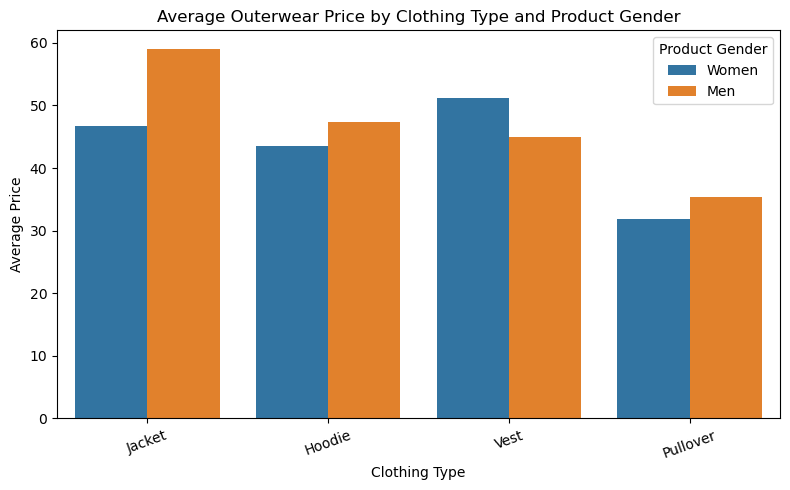

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=outerwear_df,
    x='Clothing_Type',
    y='Avg_Price',
    hue='Product_Gender',
    estimator='mean',
    errorbar=None
)
plt.xlabel('Clothing Type')
plt.ylabel('Average Price')
plt.title('Average Outerwear Price by Clothing Type and Product Gender')
plt.xticks(rotation=20)
plt.legend(title='Product Gender')
plt.tight_layout()
plt.show()

#### Visualize the number of products by Clothing_Type and Product_Gender. 

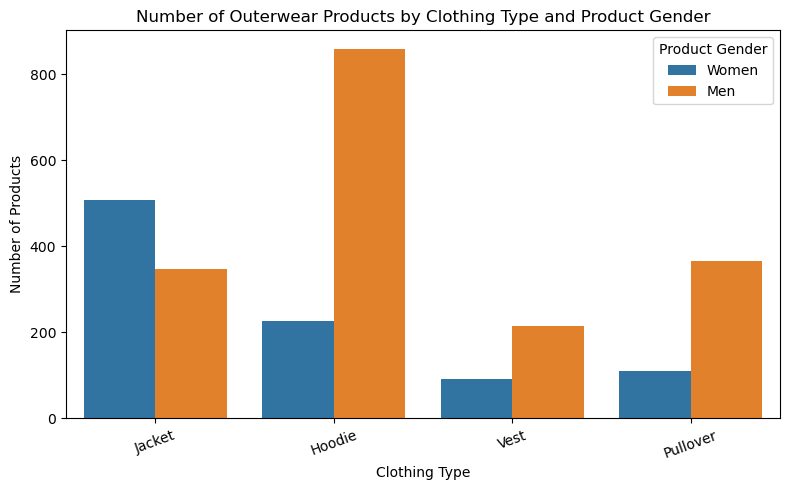

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=outerwear_df,
    x='Clothing_Type',
    hue='Product_Gender'
)
plt.xlabel('Clothing Type')
plt.ylabel('Number of Products')
plt.title('Number of Outerwear Products by Clothing Type and Product Gender')
plt.xticks(rotation=20)
plt.legend(title='Product Gender')
plt.tight_layout()
plt.show()

We plotted the mean Avg_Price by Clothing_Type and Product_Gender. This bar chart allows us to see, for each type of outerwear (hoodies, jackets, pullovers, vests), whether male- or female-associated products are priced higher on average.

And also plotted the number of products by Clothing_Type and Product_Gender to examine sample size differences across categories. This count plot helps contextualize our price comparisons by revealing where one gender has substantially more products than the other, which is important for interpreting both statistical significance and effect sizes.

#### Welch T-test

In [35]:
men_prices = outerwear_df[
    outerwear_df['Product_Gender']=='Men'
]['Avg_Price']

women_prices = outerwear_df[
    outerwear_df['Product_Gender']=='Women'
]['Avg_Price']

ttest_ind(men_prices, women_prices, equal_var=False)

TtestResult(statistic=np.float64(3.0539738325200543), pvalue=np.float64(0.0022941190042847365), df=np.float64(1664.9319838106412))

Analysis: p = 0.00229 < 0.05

A Welch’s t-test comparing mean outerwear prices between male- and female-associated products yielded a statistically significant result (t = 3.05, p = 0.002). This indicates that the observed price difference is unlikely to be due to random sampling variation.

In [36]:
mean_m = men_prices.mean()
mean_w = women_prices.mean()

std_m = men_prices.std()
std_w = women_prices.std()

n_m = len(men_prices)
n_w = len(women_prices)

pooled_std = np.sqrt(
    ((n_m - 1)*std_m**2 + (n_w - 1)*std_w**2) / (n_m + n_w - 2)
)

cohens_d = (mean_m - mean_w) / pooled_std
cohens_d

np.float64(0.12923707954374092)

Interpretation: 

Although the Welch’s t-test indicates a statistically significant difference in mean outerwear prices (p = 0.002), the calculated effect size is small (Cohen’s d = 0.13). According to conventional benchmarks, this represents a very small practical effect.

This suggests that while male-associated outerwear products are priced higher on average, the magnitude of the difference is modest. The statistical significance is likely influenced by the relatively large sample size rather than by a substantial pricing disparity.

#### Kernel density estimate (KDE) plot of Avg_Price, separated by Product_Gender

We use this visualization to examine whether price differences between male- and female-associated outerwear products are concentrated in certain price tiers (e.g., mid-range or premium products) or are consistent across the entire distribution.


<Axes: xlabel='Avg_Price', ylabel='Density'>

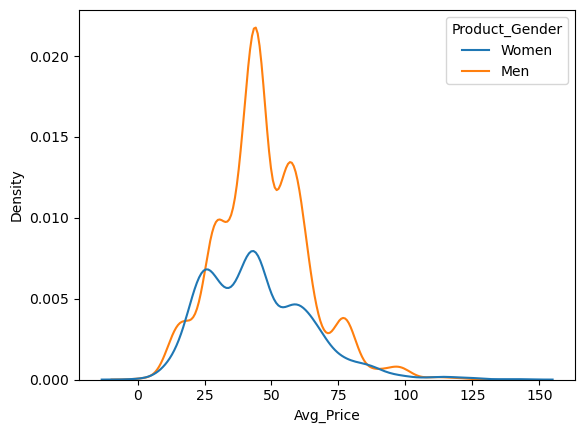

In [41]:
sns.kdeplot(data=outerwear_df, x='Avg_Price', hue='Product_Gender')

Interpretation of the Plot：

Substantial Overlap Between Distributions
The male (orange) and female (blue) price distributions overlap considerably across most price ranges. This suggests that overall pricing structures are broadly similar between genders.

Higher Density for Men in the Mid-Range ($35–$55)
The male-associated products show a stronger peak around approximately $40–$50. This aligns with earlier findings that jackets and hoodies—where male prices were higher—contribute significantly to the distribution.

Female Distribution Slightly More Spread Out
The female distribution appears somewhat more dispersed, with a flatter peak. This suggests greater variability in pricing rather than concentration in a single dominant price band.

Right-Skewed Distribution
Both distributions show a long right tail, indicating the presence of higher-priced outerwear items. However, extreme high-price items are relatively rare for both groups.


#### Outerwear Subset Summary

After restricting the dataset to clearly defined outerwear items (jackets, hoodies, pullovers, and vests), we examined whether female-associated clothing commands a higher unit price than male-associated clothing.

Descriptive statistics show that male-associated outerwear has a higher mean price overall. This pattern remains consistent within most clothing types: jackets, hoodies, and pullovers are priced higher on average for male-associated products. The vest category is the only exception, where female-associated items have a higher mean price; however, this category represents a smaller portion of the dataset and does not reverse the overall trend.

A Welch’s t-test indicates that the overall price difference between male- and female-associated outerwear is statistically significant (p < 0.05). However, the effect size is small (Cohen’s d ≈ 0.13), suggesting that the magnitude of the difference is modest in practical terms. In other words, while the difference is unlikely to be due to random sampling variation, it is not economically large.

Visualizations of the price distributions further confirm substantial overlap between genders, with male-associated products slightly more concentrated in the mid-range price band. There is no strong evidence that female-associated outerwear dominates the premium end of the distribution.

Overall, within the outerwear subset, the data do not support the hypothesis that female-associated clothing commands a higher unit price. Instead, male-associated outerwear appears to be priced slightly higher on average, though the difference is small in magnitude.